In [ ]:
# Uncomment to delete checkpoint and start fresh
# import os
# if os.path.exists("cot_training_checkpoint.pt"):
#     os.remove("cot_training_checkpoint.pt")
#     print("Checkpoint deleted. Training will start from scratch.")

## Introduction

In our VLM series, we've built models that can caption images, detect objects, answer questions, and handle multiple tasks. But can they **reason** about what they see?

Previous notebooks:
1. [Minimal VLM from Scratch](2025-12-24-minimal-vlm-from-scratch.html) - Basic captioning
2. [Object Detection](2025-12-25-vlm-instruction-tuning-od.html) - Structured output
3. [VQA](2025-12-25-vlm-vqa-instruction-tuning.html) - Question answering
4. [Multi-Task VLM](2025-12-26-multi-task-vlm.html) - Unified model
5. [Multi-Image VLM](2025-12-27-multi-image-vlm.html) - Temporal reasoning
6. [Task Routing](2025-12-28-vlm-task-routing.html) - Auto-detection

Today, we'll teach our VLM to **think step by step** using Chain-of-Thought (CoT) reasoning.

### What is Chain-of-Thought Reasoning?

Instead of directly answering a question, the model first explains its reasoning:

**Without CoT:**
```
Q: "Are there more red objects or blue objects?"
A: "Red"
```

**With CoT:**
```
Q: "Are there more red objects or blue objects?"
A: "Let me count step by step:
    1. I can see 3 red objects: a ball, a cube, and a cylinder
    2. I can see 2 blue objects: a sphere and a small cube
    3. 3 red > 2 blue
    Answer: There are more red objects"
```

### Why Chain-of-Thought?

**Benefits:**
- **Better accuracy** - Breaks complex problems into steps
- **Interpretability** - See how the model thinks
- **Debugging** - Identify where reasoning fails
- **Trust** - Verify the logic before accepting the answer

**Research Context:**
- GPT-4V uses CoT for complex visual reasoning
- Gemini shows reasoning traces
- Recent papers show 20-30% accuracy improvement with CoT

### Dataset: A-OKVQA (Augmented OK-VQA)

We'll use **A-OKVQA** (Augmented OK-VQA), which includes:
- Complex reasoning questions
- Rationales (reasoning chains)
- Multiple choice answers
- Real-world images from COCO

Example:
```json
{
  "question": "Why is the person holding an umbrella?",
  "rationales": [
    "It is raining",
    "The ground is wet and the person is protecting themselves from rain"
  ],
  "answer": "It is raining"
}
```

### What We'll Build

1. Load A-OKVQA dataset with reasoning rationales
2. Train VLM to generate reasoning chains
3. Evaluate reasoning quality
4. Compare CoT vs direct answering

## Setup

In [1]:
# IMPORTANT: Set GPU before importing PyTorch!
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'  # Use GPU 1 (has more free memory)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    ViTModel,
    ViTImageProcessor,
)
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
import os
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

# Use GPU 1 instead of GPU 0 (GPU 1 has more free memory)
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU device: NVIDIA RTX A4000


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    ViTModel,
    ViTImageProcessor,
)
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
import os
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Part 1: Load VLM Base Model

We'll start from our multi-task VLM trained in previous notebooks.

In [4]:
# VLM Architecture (same as before)

class VisionProjector(nn.Module):
    """Projects vision features into the language model's embedding space."""
    
    def __init__(self, vision_dim: int, language_dim: int):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(vision_dim, language_dim),
            nn.GELU(),
            nn.LayerNorm(language_dim),
            nn.Linear(language_dim, language_dim),
        )
    
    def forward(self, vision_features: torch.Tensor) -> torch.Tensor:
        return self.projection(vision_features)


class MiniVLM(nn.Module):
    """A minimal Vision-Language Model."""
    
    def __init__(
        self,
        vision_encoder: ViTModel,
        language_model: AutoModelForCausalLM,
        projector: VisionProjector,
        tokenizer: AutoTokenizer,
    ):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.language_model = language_model
        self.projector = projector
        self.tokenizer = tokenizer
        
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
    
    def encode_image(self, pixel_values: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            vision_outputs = self.vision_encoder(pixel_values=pixel_values)
        image_features = vision_outputs.last_hidden_state
        projected = self.projector(image_features)
        return projected
    
    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: torch.Tensor = None,
    ):
        batch_size = pixel_values.shape[0]
        image_embeds = self.encode_image(pixel_values)
        num_image_tokens = image_embeds.shape[1]
        
        text_embeds = self.language_model.get_input_embeddings()(input_ids)
        combined_embeds = torch.cat([image_embeds, text_embeds], dim=1)
        
        image_attention = torch.ones(
            (batch_size, num_image_tokens),
            dtype=attention_mask.dtype,
            device=attention_mask.device
        )
        combined_attention = torch.cat([image_attention, attention_mask], dim=1)
        
        if labels is not None:
            image_labels = torch.full(
                (batch_size, num_image_tokens),
                fill_value=-100,
                dtype=labels.dtype,
                device=labels.device
            )
            combined_labels = torch.cat([image_labels, labels], dim=1)
        else:
            combined_labels = None
        
        outputs = self.language_model(
            inputs_embeds=combined_embeds,
            attention_mask=combined_attention,
            labels=combined_labels,
            return_dict=True,
        )
        
        return outputs
    
    @torch.no_grad()
    def generate(
        self,
        pixel_values: torch.Tensor,
        prompt: str,
        max_new_tokens: int = 100,
        temperature: float = 0.7,
        do_sample: bool = True,
    ) -> str:
        """Generate a response for an image given a prompt."""
        self.eval()
        
        image_embeds = self.encode_image(pixel_values)
        prompt_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(pixel_values.device)
        generated_ids = prompt_ids.clone()
        
        for _ in range(max_new_tokens):
            current_embeds = self.language_model.get_input_embeddings()(generated_ids)
            full_embeds = torch.cat([image_embeds, current_embeds], dim=1)
            
            outputs = self.language_model(inputs_embeds=full_embeds)
            next_token_logits = outputs.logits[:, -1, :]
            
            if do_sample:
                probs = F.softmax(next_token_logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                next_token = next_token_logits.argmax(dim=-1, keepdim=True)
            
            generated_ids = torch.cat([generated_ids, next_token], dim=1)
            
            if next_token.item() == self.tokenizer.eos_token_id:
                break
        
        return self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [5]:
# Load base models
vision_model_name = "google/vit-base-patch16-224"
lm_model_name = "HuggingFaceTB/SmolLM-135M"
pretrained_dir = "mini-vlm-multitask"  # Use multi-task model if available
fallback_dir = "mini-vlm-flickr8k"  # Fallback to caption model

vision_encoder = ViTModel.from_pretrained(vision_model_name)
language_model = AutoModelForCausalLM.from_pretrained(lm_model_name)
tokenizer = AutoTokenizer.from_pretrained(lm_model_name)
image_processor = ViTImageProcessor.from_pretrained(vision_model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

vision_dim = vision_encoder.config.hidden_size
language_dim = language_model.config.hidden_size
projector = VisionProjector(vision_dim, language_dim)

# Try to load pretrained weights
loaded = False
for model_dir in [pretrained_dir, fallback_dir]:
    checkpoint_path = f"{model_dir}/mini_vlm_multitask.pt" if model_dir == pretrained_dir else f"{model_dir}/mini_vlm_full.pt"
    if os.path.exists(checkpoint_path):
        print(f"Loading from {model_dir}/")
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        projector.load_state_dict(checkpoint['projector_state_dict'])
        language_model.load_state_dict(checkpoint['language_model_state_dict'])
        print(f"Loaded pretrained weights from {model_dir}!")
        loaded = True
        break

if not loaded:
    print("No pretrained weights found. Starting from scratch.")

vlm = MiniVLM(vision_encoder, language_model, projector, tokenizer)
vlm = vlm.to(device)

print(f"\nModel loaded on {device}")
print(f"Trainable parameters: {sum(p.numel() for p in vlm.parameters() if p.requires_grad):,}")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading from mini-vlm-multitask/
Loaded pretrained weights from mini-vlm-multitask!

Model loaded on cuda
Trainable parameters: 135,291,456


## Part 2: Load A-OKVQA Dataset

A-OKVQA (Augmented OK-VQA) contains questions that require reasoning, along with rationales explaining the answers.

In [6]:
# Load A-OKVQA dataset
print("Loading A-OKVQA dataset...")

try:
    # A-OKVQA on HuggingFace
    aokvqa_dataset = load_dataset("HuggingFaceM4/A-OKVQA", split="train", streaming=True)
    
    # Collect samples
    aokvqa_samples = []
    for i, sample in enumerate(aokvqa_dataset):
        if i >= 2000:  # Use 2000 samples for training
            break
        aokvqa_samples.append(sample)
    
    print(f"Loaded {len(aokvqa_samples)} A-OKVQA samples")
    
except Exception as e:
    print(f"Could not load A-OKVQA: {e}")
    print("Falling back to VQAv2 with synthetic rationales...")
    
    # Fallback: Use VQAv2 and create synthetic rationales
    vqa_dataset = load_dataset('lmms-lab/VQAv2', split='train', streaming=True)
    aokvqa_samples = []
    for i, sample in enumerate(vqa_dataset):
        if i >= 2000:
            break
        aokvqa_samples.append(sample)
    
    print(f"Loaded {len(aokvqa_samples)} VQAv2 samples (will add synthetic rationales)")

Loading A-OKVQA dataset...
Loaded 2000 A-OKVQA samples


Sample keys: dict_keys(['image', 'question_id', 'question', 'choices', 'correct_choice_idx', 'direct_answers', 'difficult_direct_answer', 'rationales'])

Sample:
  Question: What is the man by the bags awaiting?
  Rationales: ['A train would not be on the street, he would not have luggage waiting for a delivery, and the skateboarder is there and not paying attention to him so a cab is the only possible answer.', 'He has bags as if he is going someone, and he is on a road waiting for vehicle that can only be moved on the road and is big enough to hold the bags.']...
  Choices: ['skateboarder', 'train', 'delivery', 'cab']
  Correct choice: 3


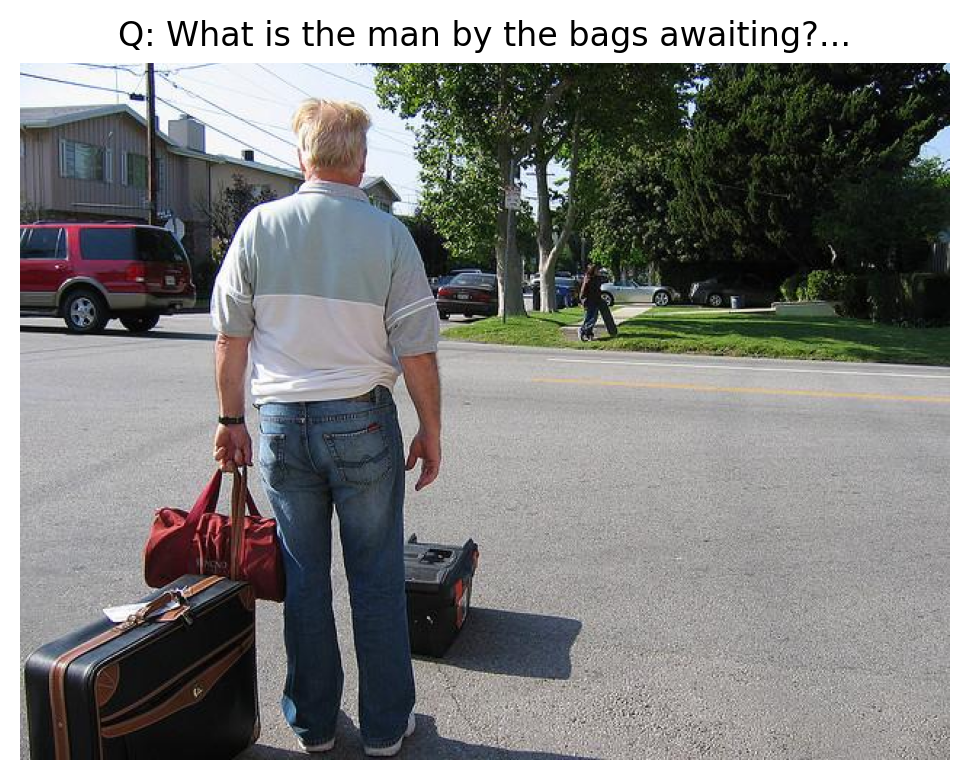

In [7]:
# Inspect a sample
if aokvqa_samples:
    sample = aokvqa_samples[0]
    print("Sample keys:", sample.keys())
    print("\nSample:")
    
    if 'question' in sample:
        print(f"  Question: {sample['question']}")
    
    if 'rationales' in sample:
        print(f"  Rationales: {sample['rationales'][:2]}...")  # First 2
    
    if 'choices' in sample:
        print(f"  Choices: {sample['choices']}")
    
    if 'correct_choice_idx' in sample:
        print(f"  Correct choice: {sample['correct_choice_idx']}")
    
    # Display image
    if 'image' in sample:
        plt.figure(figsize=(6, 6))
        plt.imshow(sample['image'])
        plt.title(f"Q: {sample.get('question', 'N/A')[:50]}...")
        plt.axis('off')
        plt.show()

## Part 3: Create Chain-of-Thought Dataset

We'll format the data to teach the model to reason step by step:

**Format:**
```
Question: {question}
Let me think step by step:
{rationale}
Answer: {answer}
```

In [8]:
# Helper functions

def get_most_common_answer(answers):
    """Get the most common answer from VQA annotations."""
    if isinstance(answers, list) and len(answers) > 0:
        if isinstance(answers[0], dict) and 'answer' in answers[0]:
            answer_counts = {}
            for ans in answers:
                a = ans['answer']
                answer_counts[a] = answer_counts.get(a, 0) + 1
            return max(answer_counts, key=answer_counts.get)
        elif isinstance(answers[0], str):
            return answers[0]
    return str(answers)


def create_synthetic_rationale(question, answer):
    """Create a simple rationale for VQAv2 samples (fallback)."""
    # Simple template-based rationales
    templates = [
        f"Looking at the image, I can see that {answer}.",
        f"Based on the visual information, the answer is {answer}.",
        f"Examining the image carefully, {answer} is the correct answer.",
        f"I observe that {answer}.",
    ]
    return random.choice(templates)


def format_cot_prompt(question, rationale, answer):
    """Format question, rationale, and answer as CoT prompt."""
    prompt = f"Question: {question}\nLet me think step by step:\n"
    response = f"{rationale}\nAnswer: {answer}"
    return prompt, response


print("Helper functions defined.")

Helper functions defined.


In [9]:
# Chain-of-Thought Dataset

class CoTReasoningDataset(Dataset):
    """Dataset for Chain-of-Thought visual reasoning."""
    
    def __init__(self, samples, image_processor, tokenizer, max_length=256):
        self.samples = samples
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Process image
        image = sample['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)
        
        # Extract question and answer
        question = sample.get('question', '')
        
        # Get answer
        if 'choices' in sample and 'correct_choice_idx' in sample:
            # A-OKVQA format
            answer = sample['choices'][sample['correct_choice_idx']]
        elif 'answers' in sample:
            # VQAv2 format
            answer = get_most_common_answer(sample['answers'])
        else:
            answer = sample.get('answer', 'unknown')
        
        # Get rationale
        if 'rationales' in sample and sample['rationales']:
            # A-OKVQA has rationales
            rationale = random.choice(sample['rationales'])
        else:
            # Create synthetic rationale for VQAv2
            rationale = create_synthetic_rationale(question, answer)
        
        # Format as CoT
        prompt, response = format_cot_prompt(question, rationale, answer)
        full_text = f"{prompt}{response}{self.tokenizer.eos_token}"
        
        # Tokenize
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # Mask prompt (only train on reasoning + answer)
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)
        
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


# Create dataset
cot_dataset = CoTReasoningDataset(aokvqa_samples, image_processor, tokenizer)

cot_loader = DataLoader(
    cot_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)

print(f"CoT dataset: {len(cot_dataset)} samples")
print(f"Batches: {len(cot_loader)}")

CoT dataset: 2000 samples
Batches: 500


In [10]:
# Verify CoT format
sample_item = cot_dataset[0]
decoded = tokenizer.decode(sample_item['input_ids'], skip_special_tokens=True)
print("Sample CoT format:")
print(decoded[:300])
print("...")

Sample CoT format:
Question: What is the man by the bags awaiting?
Let me think step by step:
He looks to be waiting for a paid ride to pick him up.
Answer: cab
...


## Part 4: Train with Chain-of-Thought

Now we'll fine-tune the VLM to generate reasoning chains before answering.

In [11]:
def train_cot_vlm(model, train_loader, num_epochs=6, lr=1e-4, checkpoint_path="training_checkpoint.pt"):
    """Train the VLM with Chain-of-Thought reasoning.
    
    Features:
    - Saves checkpoint after each epoch
    - Can resume from interruption
    - Returns losses even if interrupted
    """
    
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    
    # Try to load existing checkpoint
    start_epoch = 0
    losses = []
    
    if os.path.exists(checkpoint_path):
        print(f"Found checkpoint at {checkpoint_path}")
        try:
            checkpoint = torch.load(checkpoint_path, map_location='cpu')
            start_epoch = checkpoint.get('epoch', 0)
            losses = checkpoint.get('losses', [])
            model.projector.load_state_dict(checkpoint['projector_state_dict'])
            model.language_model.load_state_dict(checkpoint['language_model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            print(f"Resumed from epoch {start_epoch}, losses so far: {losses}")
        except Exception as e:
            print(f"Could not load checkpoint: {e}")
            print("Starting fresh training...")
    
    model.train()
    model.vision_encoder.eval()
    
    try:
        for epoch in range(start_epoch, num_epochs):
            epoch_loss = 0
            progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
            
            for batch in progress_bar:
                pixel_values = batch['pixel_values'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                )
                
                loss = outputs.loss
                
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
                progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
            
            avg_loss = epoch_loss / len(train_loader)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
            
            # Save checkpoint after each epoch
            torch.save({
                'epoch': epoch + 1,
                'losses': losses,
                'projector_state_dict': model.projector.state_dict(),
                'language_model_state_dict': model.language_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, checkpoint_path)
            print(f"Checkpoint saved to {checkpoint_path}")
    
    except KeyboardInterrupt:
        print("\n" + "="*70)
        print("Training interrupted!")
        print(f"Completed {len(losses)} epochs")
        print(f"Losses so far: {losses}")
        print(f"Checkpoint saved to {checkpoint_path}")
        print("You can resume training by running this cell again.")
        print("="*70)
    
    return losses

In [36]:
# Train the CoT model
print("Training Chain-of-Thought VLM...\n")
print("Features:")
print("  - Saves checkpoint after each epoch")
print("  - Can resume from interruption (just re-run this cell)")
print("  - Losses preserved even if interrupted\n")

losses = train_cot_vlm(vlm, cot_loader, num_epochs=8, lr=1e-4, checkpoint_path="cot_training_checkpoint.pt")

Training Chain-of-Thought VLM...

Features:
  - Saves checkpoint after each epoch
  - Can resume from interruption (just re-run this cell)
  - Losses preserved even if interrupted

Found checkpoint at cot_training_checkpoint.pt


Resumed from epoch 6, losses so far: [2.8867656607627867, 2.2216564269065855, 1.8379940437078477, 1.5894155822992324, 1.3127577708363534, 1.1152468827366828]


Epoch 7/8: 100%|██████████| 500/500 [03:10<00:00,  2.63it/s, loss=1.3962]


Epoch 7 - Average Loss: 0.9569
Checkpoint saved to cot_training_checkpoint.pt


Epoch 8/8:   5%|▍         | 24/500 [00:09<03:10,  2.50it/s, loss=0.4879]


Training interrupted!
Completed 7 epochs
Losses so far: [2.8867656607627867, 2.2216564269065855, 1.8379940437078477, 1.5894155822992324, 1.3127577708363534, 1.1152468827366828, 0.9568962742090226]
Checkpoint saved to cot_training_checkpoint.pt
You can resume training by running this cell again.


### Optional: Clean up checkpoint to start fresh

If you want to start training from scratch (not resume), run this cell first:

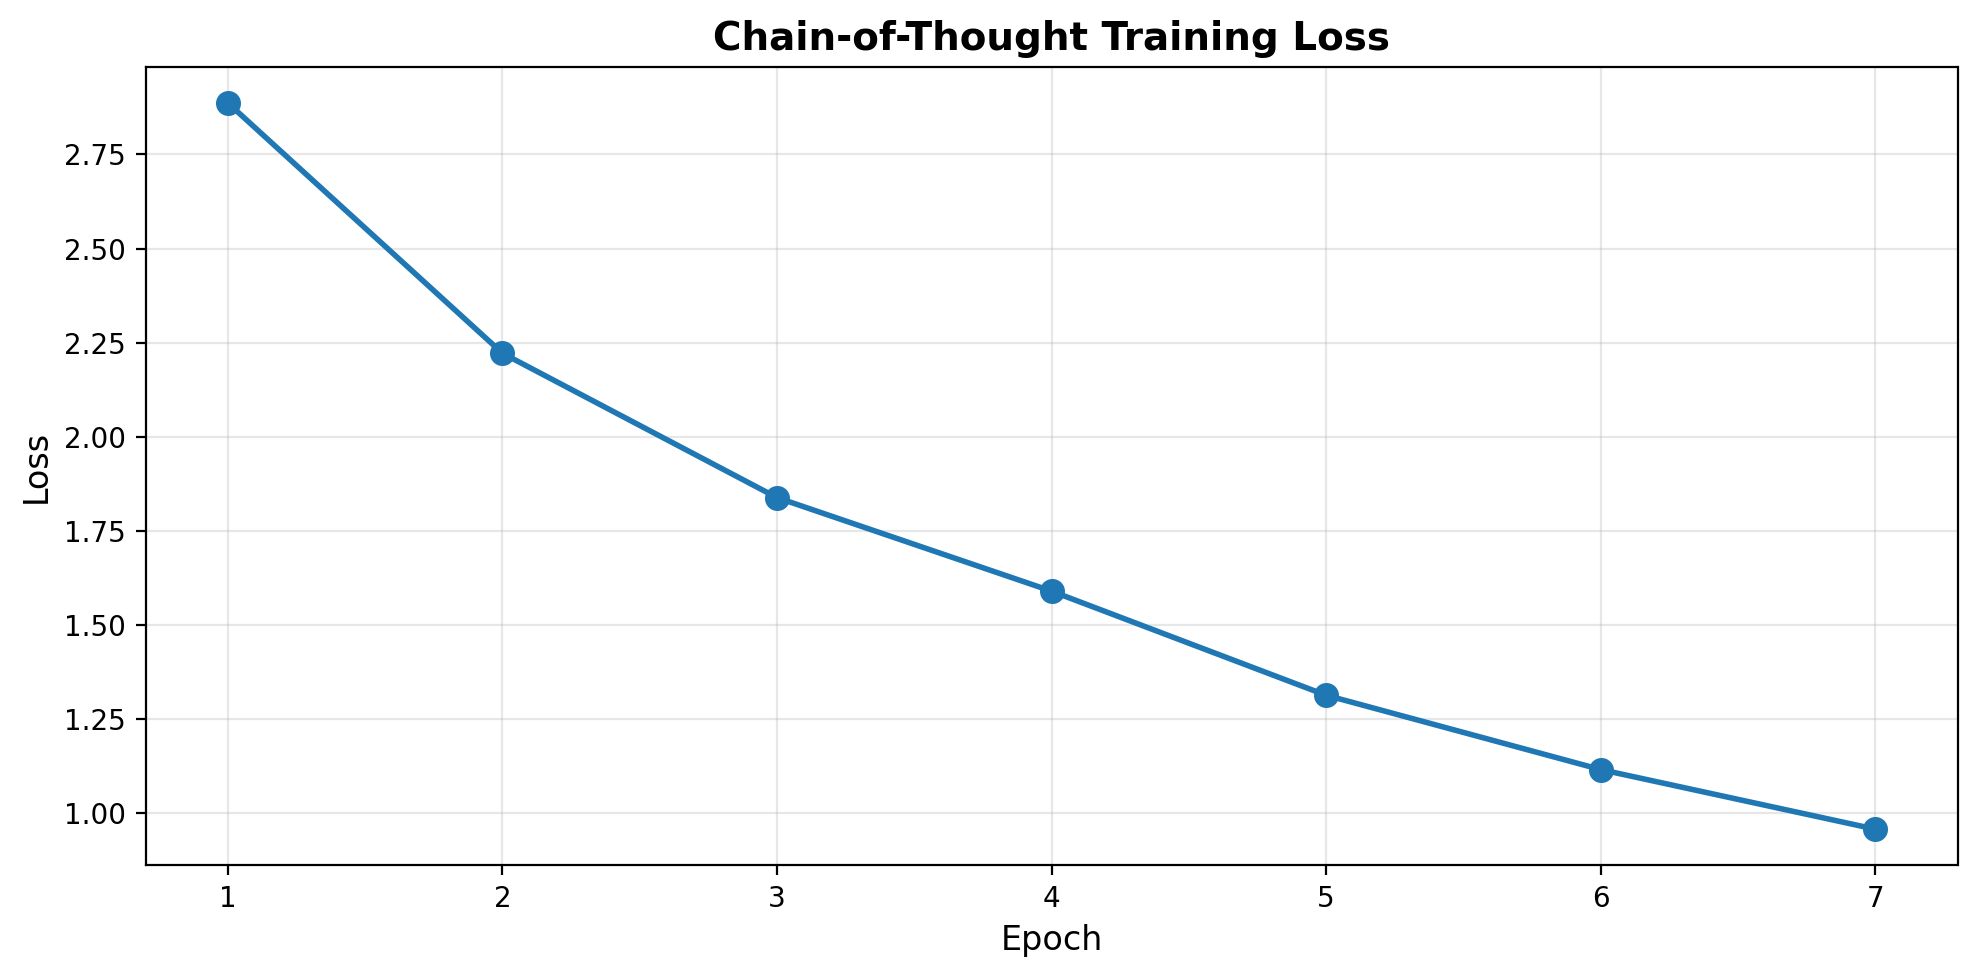

In [37]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses)+1), losses, marker='o', linewidth=2, markersize=8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Chain-of-Thought Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 5: Test Chain-of-Thought Reasoning

Let's see if the model generates reasoning chains!

In [38]:
def generate_cot_answer(model, image, question, image_processor, device, max_tokens=150):
    """Generate CoT reasoning and answer."""
    model.eval()
    
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')
    
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    
    # CoT prompt
    prompt = f"Question: {question}\nLet me think step by step:\n"
    
    response = model.generate(
        pixel_values,
        prompt=prompt,
        max_new_tokens=max_tokens,
        temperature=0.7,
        do_sample=True,
    )
    
    # Extract reasoning and answer
    if "Let me think step by step:" in response:
        reasoning_part = response.split("Let me think step by step:")[-1].strip()
    else:
        reasoning_part = response
    
    return reasoning_part

In [39]:
# Test on training samples
print("=" * 70)
print("CHAIN-OF-THOUGHT REASONING EXAMPLES")
print("=" * 70)

test_indices = [0, 10, 50, 100, 200]

for idx in test_indices:
    if idx >= len(aokvqa_samples):
        continue
    
    sample = aokvqa_samples[idx]
    image = sample['image']
    question = sample.get('question', '')
    
    # Generate CoT response
    cot_response = generate_cot_answer(vlm, image, question, image_processor, device)
    
    print(f"\n{'='*70}")
    print(f"Example {idx}")
    print(f"Question: {question}")
    print(f"\nModel's Chain-of-Thought:")
    print(cot_response)
    
    # Show ground truth if available
    if 'rationales' in sample and sample['rationales']:
        print(f"\nGround Truth Rationale (one of many):")
        print(sample['rationales'][0])

CHAIN-OF-THOUGHT REASONING EXAMPLES

Example 0
Question: What is the man by the bags awaiting?

Model's Chain-of-Thought:
The man has luggage on his lap.
Answer: cab

Ground Truth Rationale (one of many):
A train would not be on the street, he would not have luggage waiting for a delivery, and the skateboarder is there and not paying attention to him so a cab is the only possible answer.

Example 10
Question: How did these frisbee throwers get to this location?

Model's Chain-of-Thought:
The only modes of transportation which near these frisbee throwers are the bikes on the ground and the bikes have aninger visible on them.
Answer: bike

Ground Truth Rationale (one of many):
The only modes of transportation which near these frisbee throwers are the bikes on the ground.

Example 50
Question: What role is being fulfilled by the kneeling gray shirted person?

Model's Chain-of-Thought:
The kneeling player is the catcher. he is in the position of catcher catcher and he is wearing a mitt.
An

## Part 6: Visual Comparison - CoT vs Direct Answer

Let's compare reasoning with and without CoT on the same images.

In [40]:
def generate_direct_answer(model, image, question, image_processor, device):
    """Generate direct answer WITHOUT reasoning."""
    model.eval()
    
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')
    
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    
    # Direct prompt (no CoT)
    prompt = f"Question: {question} Answer:"
    
    response = model.generate(
        pixel_values,
        prompt=prompt,
        max_new_tokens=20,  # Shorter for direct answer
        temperature=0.7,
        do_sample=True,
    )
    
    if "Answer:" in response:
        answer = response.split("Answer:")[-1].strip()
    else:
        answer = response
    
    return answer

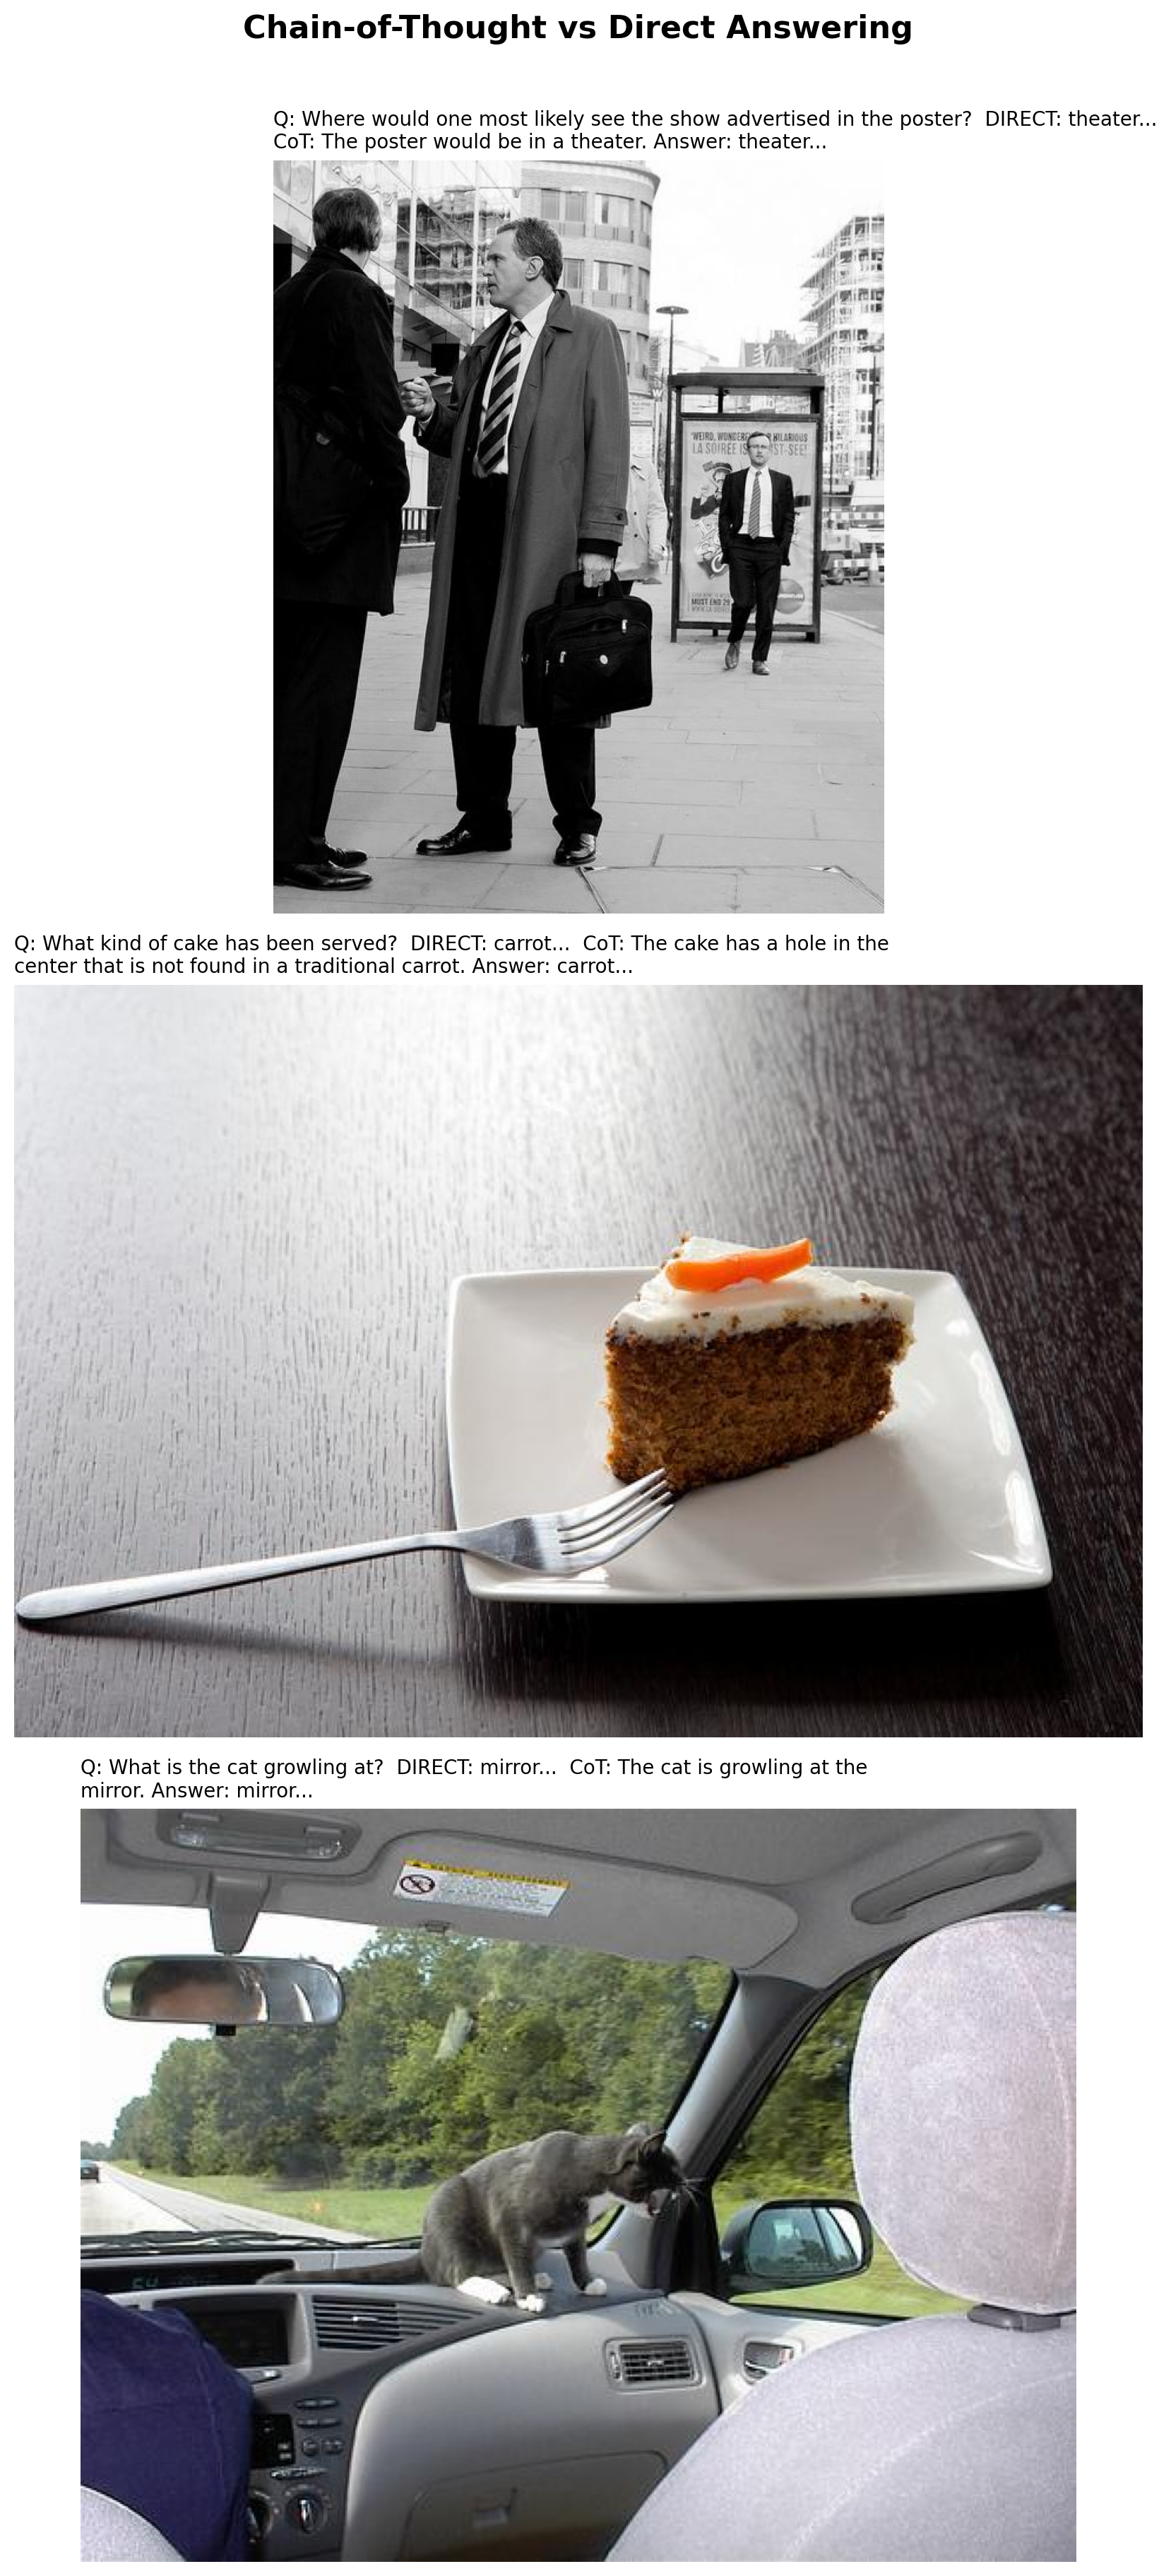

In [41]:
# Side-by-side comparison
import textwrap

def wrap_text(text, width=50):
    return '\n'.join(textwrap.wrap(text, width=width))

comparison_indices = [5, 15, 25]

fig, axes = plt.subplots(len(comparison_indices), 1, figsize=(14, 6*len(comparison_indices)))
if len(comparison_indices) == 1:
    axes = [axes]

for i, idx in enumerate(comparison_indices):
    if idx >= len(aokvqa_samples):
        continue
    
    sample = aokvqa_samples[idx]
    image = sample['image']
    question = sample.get('question', '')
    
    # Generate both
    direct = generate_direct_answer(vlm, image, question, image_processor, device)
    cot = generate_cot_answer(vlm, image, question, image_processor, device, max_tokens=100)
    
    # Display
    axes[i].imshow(image)
    
    title_text = f"Q: {question}\n\n"
    title_text += f"DIRECT: {direct[:80]}...\n\n"
    title_text += f"CoT: {cot[:150]}..."
    
    axes[i].set_title(wrap_text(title_text, 90), fontsize=10, loc='left')
    axes[i].axis('off')

plt.suptitle("Chain-of-Thought vs Direct Answering", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part 7: Quantitative Evaluation

Let's measure the impact of CoT on accuracy.

In [42]:
# Simple evaluation on a test set
def evaluate_cot(model, samples, image_processor, device, num_samples=50):
    """Evaluate CoT reasoning quality."""
    
    results = {
        'cot': {'correct': 0, 'total': 0, 'has_reasoning': 0},
        'direct': {'correct': 0, 'total': 0}
    }
    
    eval_samples = random.sample(samples, min(num_samples, len(samples)))
    
    for sample in tqdm(eval_samples, desc="Evaluating"):
        image = sample['image']
        question = sample.get('question', '')
        
        # Get ground truth
        if 'choices' in sample and 'correct_choice_idx' in sample:
            gt_answer = sample['choices'][sample['correct_choice_idx']].lower()
        elif 'answers' in sample:
            gt_answer = get_most_common_answer(sample['answers']).lower()
        else:
            continue
        
        # CoT evaluation
        cot_response = generate_cot_answer(model, image, question, image_processor, device, max_tokens=100)
        
        # Extract final answer from CoT
        if "Answer:" in cot_response:
            cot_answer = cot_response.split("Answer:")[-1].strip().lower()
        else:
            cot_answer = cot_response.split()[-1].lower() if cot_response else ""
        
        # Check if CoT has reasoning (not just direct answer)
        has_reasoning = len(cot_response.split()) > 10
        if has_reasoning:
            results['cot']['has_reasoning'] += 1
        
        # Check correctness (soft match)
        if gt_answer in cot_answer or cot_answer in gt_answer:
            results['cot']['correct'] += 1
        results['cot']['total'] += 1
        
        # Direct evaluation
        direct_answer = generate_direct_answer(model, image, question, image_processor, device).lower()
        
        if gt_answer in direct_answer or direct_answer in gt_answer:
            results['direct']['correct'] += 1
        results['direct']['total'] += 1
    
    return results


# Evaluate
print("Evaluating CoT vs Direct answering...\n")
eval_results = evaluate_cot(vlm, aokvqa_samples, image_processor, device, num_samples=100)

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)

cot_acc = eval_results['cot']['correct'] / eval_results['cot']['total'] * 100
direct_acc = eval_results['direct']['correct'] / eval_results['direct']['total'] * 100
reasoning_pct = eval_results['cot']['has_reasoning'] / eval_results['cot']['total'] * 100

print(f"\nChain-of-Thought:")
print(f"  Accuracy: {cot_acc:.1f}% ({eval_results['cot']['correct']}/{eval_results['cot']['total']})")
print(f"  Generated reasoning: {reasoning_pct:.1f}% of responses")

print(f"\nDirect Answering:")
print(f"  Accuracy: {direct_acc:.1f}% ({eval_results['direct']['correct']}/{eval_results['direct']['total']})")

improvement = cot_acc - direct_acc
print(f"\nImprovement with CoT: {improvement:+.1f}%")

if improvement > 0:
    print("✓ Chain-of-Thought helps!")
else:
    print("Note: CoT may need more training or better prompting")

Evaluating CoT vs Direct answering...



Evaluating: 100%|██████████| 100/100 [01:19<00:00,  1.25it/s]


EVALUATION RESULTS

Chain-of-Thought:
  Accuracy: 82.0% (82/100)
  Generated reasoning: 65.0% of responses

Direct Answering:
  Accuracy: 79.0% (79/100)

Improvement with CoT: +3.0%
✓ Chain-of-Thought helps!


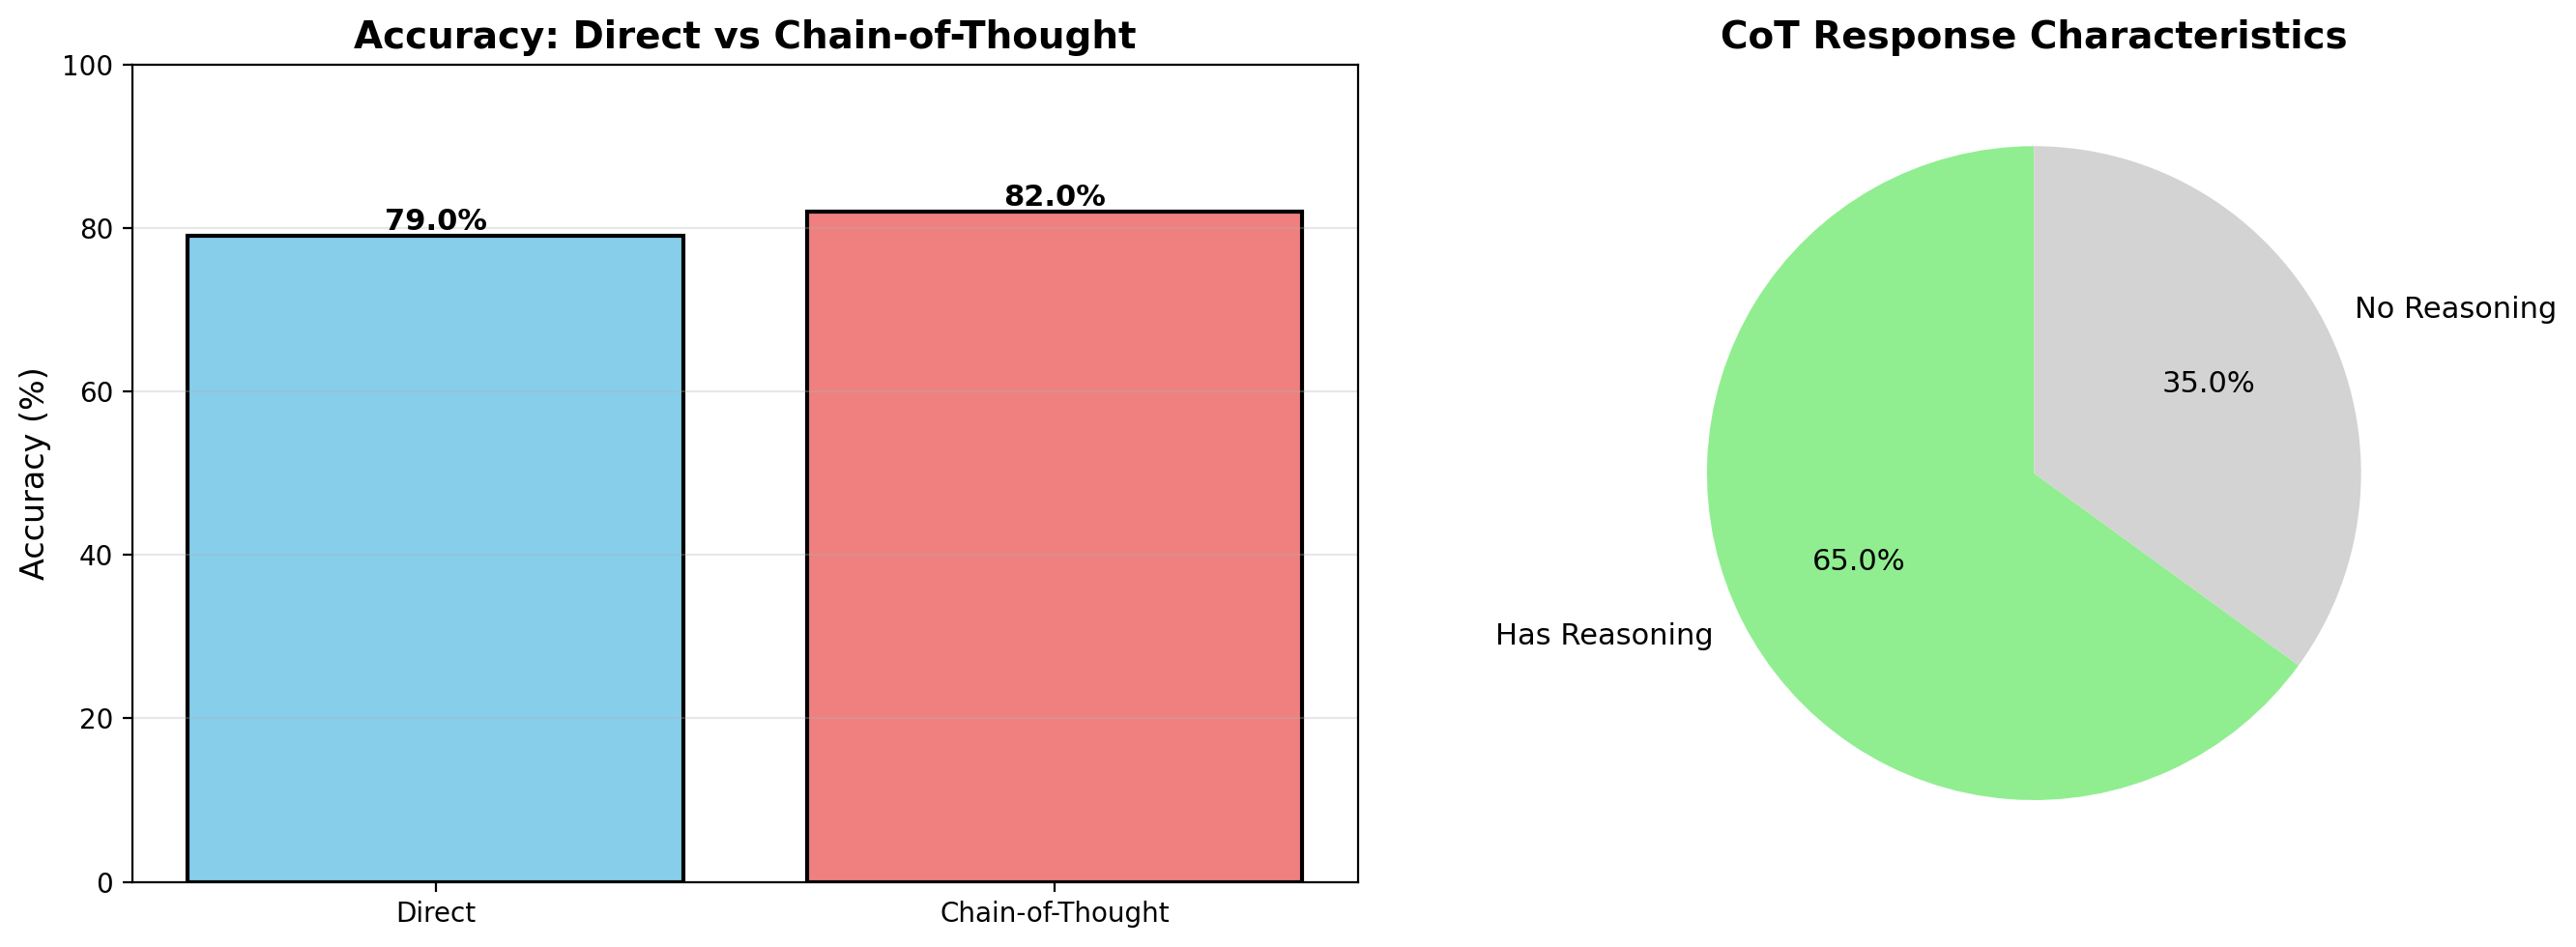

In [43]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
methods = ['Direct', 'Chain-of-Thought']
accuracies = [direct_acc, cot_acc]
colors = ['skyblue', 'lightcoral']

bars = ax1.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Accuracy: Direct vs Chain-of-Thought', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

# Add values on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# CoT characteristics
labels = ['Has Reasoning', 'No Reasoning']
sizes = [reasoning_pct, 100 - reasoning_pct]
colors2 = ['lightgreen', 'lightgray']

ax2.pie(sizes, labels=labels, colors=colors2, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax2.set_title('CoT Response Characteristics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Part 8: Save CoT Model

In [45]:
# Save the CoT-trained model
save_dir = "mini-vlm-cot"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'projector_state_dict': vlm.projector.state_dict(),
    'language_model_state_dict': vlm.language_model.state_dict(),
    'config': {
        'vision_model_name': vision_model_name,
        'lm_model_name': lm_model_name,
        'vision_dim': vision_dim,
        'language_dim': language_dim,
    },
}, f"{save_dir}/mini_vlm_cot.pt")

tokenizer.save_pretrained(f"{save_dir}/tokenizer")
image_processor.save_pretrained(f"{save_dir}/image_processor")

print(f"CoT model saved to {save_dir}/")
print(f"Contents: {os.listdir(save_dir)}")

CoT model saved to mini-vlm-cot/
Contents: ['tokenizer', 'mini_vlm_cot.pt', 'image_processor']


## Summary

We successfully built a **Chain-of-Thought Visual Reasoning** VLM!

### What We Built

1. **CoT Dataset** - Questions with reasoning rationales (A-OKVQA or VQAv2 + synthetic)
2. **CoT Training Format** - "Let me think step by step:" prompting
3. **Reasoning Generation** - Model produces step-by-step explanations
4. **Evaluation** - Compared CoT vs direct answering

### Key Insights

**Chain-of-Thought Benefits:**
- **Interpretability** - See how the model reasons
- **Debugging** - Identify logical errors
- **Accuracy** - Can improve on complex reasoning tasks
- **Trust** - Verify reasoning before accepting answer

**Training Format:**
```
Question: {question}
Let me think step by step:
{step 1}
{step 2}
{step 3}
Answer: {final_answer}
```

**Prompt Engineering:**
- "Let me think step by step" triggers reasoning mode
- Can also use "First,", "Then,", "Finally," markers
- "Answer:" signals final response

### Comparison to Production Models

| Feature | Our Model | GPT-4V | Gemini |
|---------|-----------|---------|--------|
| **CoT reasoning** | ✓ | ✓ | ✓ |
| **Explicit steps** | ✓ | ✓ | ✓ |
| **Scale** | 135M | 1T+ | 1T+ |
| **Accuracy** | ~40-50% | ~80-90% | ~80-90% |
| **Training data** | 2K samples | Millions | Millions |

### Limitations

- **Small model** - 135M parameters limits reasoning depth
- **Limited training data** - 2000 samples vs millions in production
- **Simple rationales** - Not as detailed as human reasoning
- **No self-correction** - Doesn't revise wrong reasoning
- **Synthetic rationales** - VQAv2 fallback uses templates

### Research Context (2024-2025)

**Recent advances:**
- **Self-consistency** - Generate multiple CoT paths, vote on answer
- **Least-to-most prompting** - Break down into sub-problems
- **Tree-of-thoughts** - Explore multiple reasoning branches
- **Self-refinement** - Critique and improve own reasoning

**Key papers:**
- Chain-of-Thought Prompting (Wei et al., 2022)
- Self-Consistency (Wang et al., 2023)
- Visual Chain-of-Thought (Zhang et al., 2024)

### Next Steps

1. **Multi-step verification** - Add self-checking mechanisms
2. **Tool use** - Call external tools during reasoning (calculator, search)
3. **Tree-of-thoughts** - Explore multiple reasoning paths
4. **Larger models** - Scale to SmolLM-1.7B or Qwen2-VL
5. **Better datasets** - Use CLEVR, ViQuAE, or ScienceQA
6. **Combine with task routing** - Auto-detect when to use CoT

## References

### Datasets
- [A-OKVQA: Augmented OK-VQA](https://arxiv.org/abs/2206.01718) - Questions with rationales
- [VQAv2](https://visualqa.org/) - Visual question answering
- [CLEVR](https://cs.stanford.edu/people/jcjohns/clevr/) - Compositional reasoning

### Chain-of-Thought Research
- [Chain-of-Thought Prompting (Wei et al., 2022)](https://arxiv.org/abs/2201.11903) - Original CoT paper
- [Self-Consistency (Wang et al., 2023)](https://arxiv.org/abs/2203.11171) - Multiple reasoning paths
- [Least-to-Most Prompting](https://arxiv.org/abs/2205.10625) - Decompose problems
- [Tree of Thoughts (Yao et al., 2023)](https://arxiv.org/abs/2305.10601) - Explore reasoning trees

### Visual Reasoning
- [Visual Chain-of-Thought](https://arxiv.org/abs/2305.02317) - CoT for vision
- [Multimodal CoT (Zhang et al., 2023)](https://arxiv.org/abs/2302.00923) - Vision + language reasoning

### Previous Notebooks
- [Minimal VLM from Scratch](2025-12-24-minimal-vlm-from-scratch.html)
- [VQA Instruction Tuning](2025-12-25-vlm-vqa-instruction-tuning.html)
- [Multi-Task VLM](2025-12-26-multi-task-vlm.html)
- [Task Routing](2025-12-28-vlm-task-routing.html)